In [7]:
import os
import tensorflow as tf

train_path = "/content/drive/MyDrive/CnnDataset/seg_train/seg_train"

print(os.listdir(train_path))
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(150, 150),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(150, 150),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)
class_names = train_dataset.class_names

print(class_names)


['street', 'mountain', 'sea', 'glacier', 'forest', 'buildings']
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


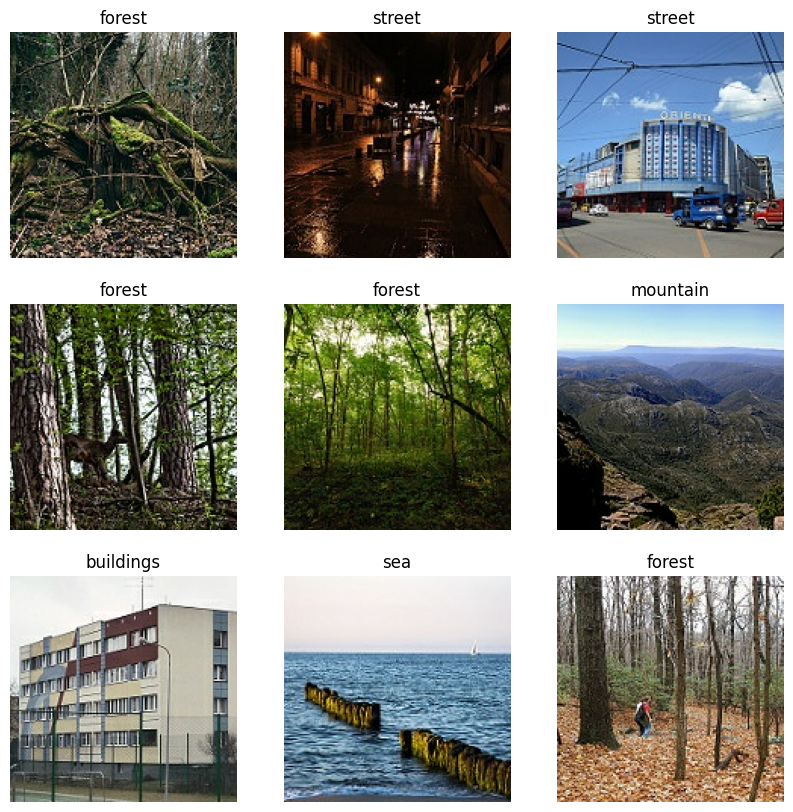

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=4
)

Epoch 1/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 1448s 4s/step - accuracy: 0.7197 - loss: 0.7554 - val_accuracy: 0.7063 - val_loss: 0.7831
Epoch 2/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.7960 - loss: 0.5519 - val_accuracy: 0.7826 - val_loss: 0.6013
Epoch 3/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8523 - loss: 0.4111 - val_accuracy: 0.7758 - val_loss: 0.6890
Epoch 4/4
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9023 - loss: 0.2729 - val_accuracy: 0.7929 - val_loss: 0.7170


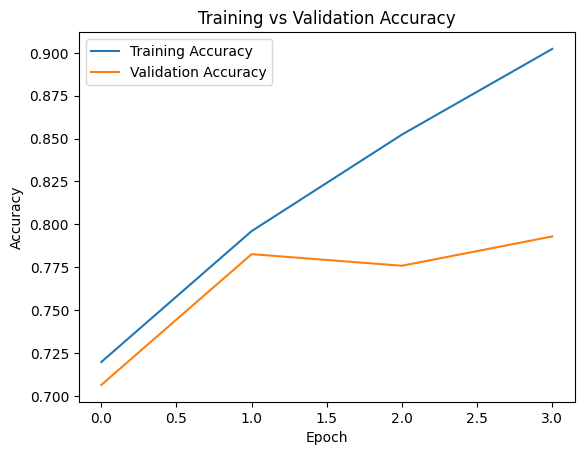

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

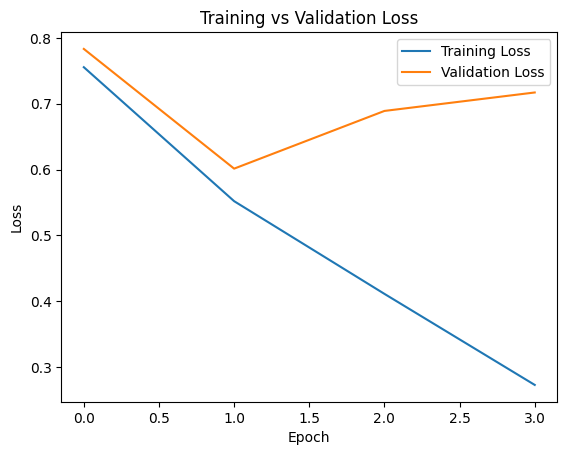

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [18]:
import os

test_path = "/content/drive/MyDrive/CnnDataset/seg_test/seg_test"

print(os.listdir(test_path))

['mountain', 'street', 'glacier', 'sea', 'buildings', 'forest']


In [19]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(150, 150),
    batch_size=32,
    shuffle=False
)
print(test_dataset.class_names)

Found 3000 files belonging to 6 classes.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [20]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 492s 5s/step - accuracy: 0.7993 - loss: 0.6743
Test Loss: 0.6743344068527222
Test Accuracy: 0.7993333339691162


In [21]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed!")

Predictions completed!


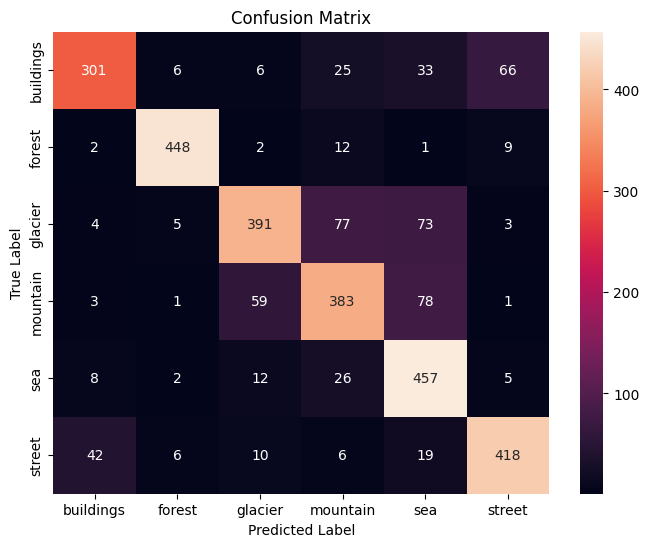

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=test_dataset.class_names,
    yticklabels=test_dataset.class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from google.colab import files

uploaded = files.upload()

Saving mountain.jpg to mountain (1).jpg


In [25]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = "mountain.jpg"

img = load_img(image_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [26]:
prediction = model.predict(img_array, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

print("Prediction:", class_names[predicted_class])
print("Confidence:", round(confidence, 2), "%")

Prediction: mountain
Confidence: 75.54 %


In [27]:
model.save("/content/model1.keras")

In [28]:
from google.colab import files

files.download("/content/model1.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>